In [34]:
import xarray as xr
import matplotlib.pyplot as plt
from glob import glob
import os
import re
import numpy as np
from itertools import cycle

In [35]:
def pl33tn(x, dt=1.0, T=33.0, mode="valid", t=None):
    """
    Computes low-passed series from `x` using pl33 filter, with optional
    sample interval `dt` (hours) and filter half-amplitude period T (hours)
    as input for non-hourly series.

    The PL33 filter is described on p. 21, Rosenfeld (1983), WHOI
    Technical Report 85-35.  Filter half amplitude period = 33 hrs.,
    half power period = 38 hrs.  The time series x is folded over
    and cosine tapered at each end to return a filtered time series
    xf of the same length.  Assumes length of x greater than 67.

    Can input a DataArray and use dask-supported for lazy execution. In that
    use case, dt is ignored and calculated from the input DataArray.
    cf-xarray is also required.

    Examples
    --------
    >>> from oceans.filters import pl33tn
    >>> import matplotlib.pyplot as plt
    >>> t = np.arange(500)  # Time in hours.
    >>> x = 2.5 * np.sin(2 * np.pi * t / 12.42)
    >>> x += 1.5 * np.sin(2 * np.pi * t / 12.0)
    >>> x += 0.3 * np.random.randn(len(t))
    >>> filtered_33 = pl33tn(x, dt=4.0)  # 33 hr filter
    >>> filtered_33d3 = pl33tn(x, dt=4.0, T=72.0)  # 3 day filter
    >>> fig, ax = plt.subplots()
    >>> (l1,) = ax.plot(t, x, label="original")
    >>> pad = [np.nan] * 8
    >>> (l2,) = ax.plot(t, np.r_[pad, filtered_33, pad], label="33 hours")
    >>> pad = [np.nan] * 17
    >>> (l3,) = ax.plot(t, np.r_[pad, filtered_33d3, pad], label="3 days")
    >>> legend = ax.legend()


    """

    # import cf_xarray  # noqa: F401
    # import pandas as pd
    # import xarray as xr

    if isinstance(x, xr.Dataset | pd.DataFrame):
        raise TypeError("Input a DataArray not a Dataset, or a Series not a DataFrame.")

    if isinstance(x, pd.Series) and not isinstance(
        x.index,
        pd.core.indexes.datetimes.DatetimeIndex,
    ):
        raise TypeError("Input Series needs to have parsed datetime indices.")

    # find dt in units of hours
    if isinstance(x, xr.DataArray):
        dt = (x.cf["T"][1] - x.cf["T"][0]) / np.timedelta64(
            3_600_000_000_000,
        )
    elif isinstance(x, pd.Series):
        dt = (x.index[1] - x.index[0]) / pd.Timedelta("1H")

    pl33 = np.array(
        [
            -0.00027,
            -0.00114,
            -0.00211,
            -0.00317,
            -0.00427,
            -0.00537,
            -0.00641,
            -0.00735,
            -0.00811,
            -0.00864,
            -0.00887,
            -0.00872,
            -0.00816,
            -0.00714,
            -0.00560,
            -0.00355,
            -0.00097,
            +0.00213,
            +0.00574,
            +0.00980,
            +0.01425,
            +0.01902,
            +0.02400,
            +0.02911,
            +0.03423,
            +0.03923,
            +0.04399,
            +0.04842,
            +0.05237,
            +0.05576,
            +0.05850,
            +0.06051,
            +0.06174,
            +0.06215,
            +0.06174,
            +0.06051,
            +0.05850,
            +0.05576,
            +0.05237,
            +0.04842,
            +0.04399,
            +0.03923,
            +0.03423,
            +0.02911,
            +0.02400,
            +0.01902,
            +0.01425,
            +0.00980,
            +0.00574,
            +0.00213,
            -0.00097,
            -0.00355,
            -0.00560,
            -0.00714,
            -0.00816,
            -0.00872,
            -0.00887,
            -0.00864,
            -0.00811,
            -0.00735,
            -0.00641,
            -0.00537,
            -0.00427,
            -0.00317,
            -0.00211,
            -0.00114,
            -0.00027,
        ],
    )

    _dt = np.linspace(-33, 33, 67)

    dt = float(dt) * (33.0 / T)

    filter_time = np.arange(0.0, 33.0, dt, dtype="d")
    Nt = len(filter_time)
    filter_time = np.hstack((-filter_time[-1:0:-1], filter_time))

    pl33 = np.interp(filter_time, _dt, pl33)
    pl33 /= pl33.sum()

    if isinstance(x, xr.DataArray):
        x = x.interpolate_na(dim=x.cf["T"].name)

        weight = xr.DataArray(pl33, dims=["window"])
        xf = (
            x.rolling({x.cf["T"].name: len(pl33)}, center=True)
            .construct({x.cf["T"].name: "window"})
            .dot(weight, dims="window")
        )
        # update attrs
        attrs = {
            key: f"{value}, filtered"
            for key, value in x.attrs.items()
            if key != "units"
        }
        xf.attrs = attrs

    elif isinstance(x, pd.Series):
        xf = x.to_frame().apply(np.convolve, v=pl33, mode=mode)

        # nan out edges which are not good values anyway
        if mode == "same":
            xf[: Nt - 1] = np.nan
            xf[-Nt + 2 :] = np.nan

    else:  # use numpy
        xf = np.convolve(x, pl33, mode=mode)

        # times to match xf
        if t is not None:
            # Nt = len(filter_time)
            tf = t[Nt - 1 : -Nt + 1]
            return xf, tf

        # nan out edges which are not good values anyway
        if mode == "same":
            xf[: Nt - 1] = np.nan
            xf[-Nt + 2 :] = np.nan

    return xf

In [36]:
# ---------------------
# Find files
# --------------------------------------------------
mix_files = sorted(glob("mixing_outputs/mixing_vavg_*.nc"))
ke_files  = sorted(glob("energy_outputs/meanKE_*.nc"))

if not mix_files:
    raise FileNotFoundError("No mixing files found")
if not ke_files:
    raise FileNotFoundError("No KE files found")

# Map resolution → file
def res_from_name(fname):
    """Extract resolution string like '10km' or '500m'"""
    return re.search(r"_(\d+km|\d+m)", fname).group(1)

mix_map = {res_from_name(f): f for f in mix_files}
ke_map  = {res_from_name(f): f for f in ke_files}

# --------------------------------------------------
# Sort resolutions numerically (low → high res)
# --------------------------------------------------
def res_key(res):
    """Return numeric grid spacing in meters for sorting."""
    if res.endswith("km"):
        return int(res[:-2]) * 1000
    elif res.endswith("m"):
        return int(res[:-1])
    else:
        raise ValueError(f"Unknown resolution format: {res}")

resolutions = sorted(set(mix_map) & set(ke_map), key=res_key)

# --------------------------------------------------
# Time array (0–60 days)
# --------------------------------------------------
dt_hours = 2
n_days = 60
time_hours = np.arange(0, n_days*24, dt_hours)  # 0, 2, 4, ..., 6*24-2
time_days  = time_hours / 24.0  # convert hours → days
time       = 60.0 * (time_days - time_days[0]) / (time_days[-1] - time_days[0])


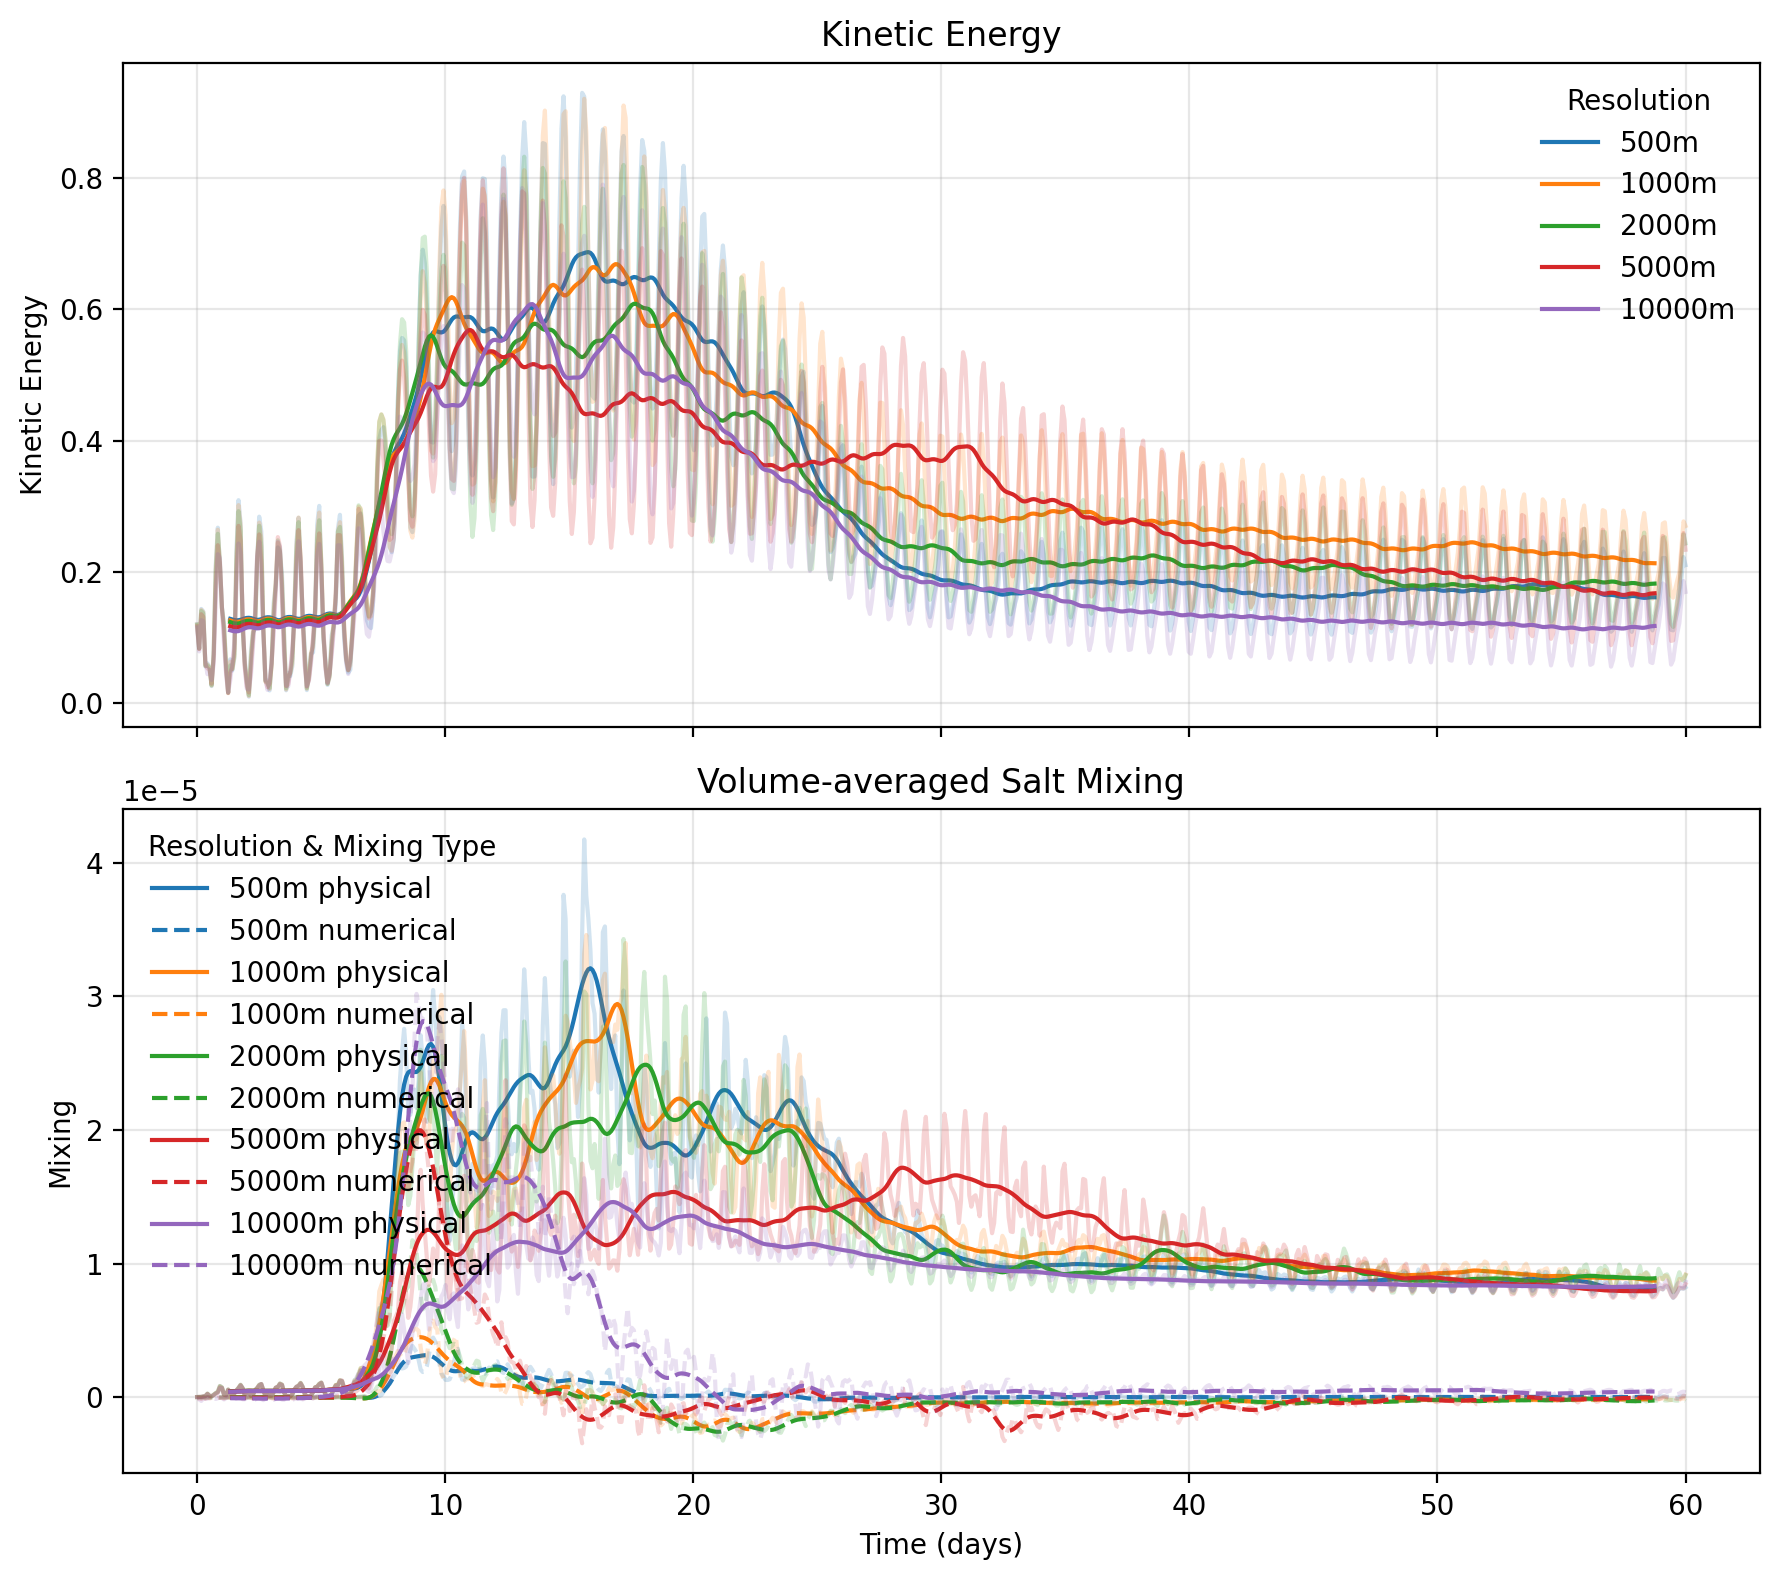

In [61]:


# --------------------------------------------------
# Figure: 2 rows, KE on top, mixing on bottom
# --------------------------------------------------
fig, axs = plt.subplots(2, 1, figsize=(9, 8), dpi = 200,sharex=True)

ax_ke  = axs[0]  # top: KE
ax_mix = axs[1]  # bottom: Mixing

# --------------------------------------------------
# Define a color cycle
# --------------------------------------------------
colors = cycle(plt.rcParams['axes.prop_cycle'].by_key()['color'])

# --------------------------------------------------
# Loop over resolutions
# --------------------------------------------------
for res in resolutions:
    dsm = xr.open_dataset(mix_map[res])
    dsk = xr.open_dataset(ke_map[res])

    color = next(colors)

    # --- Extract raw time series ---
    Mphy = dsm.Mphy_salt.values
    Mnum = dsm.Mnum_salt.values
    KE   = dsk.meanKE.values[1:]  # skip first if needed

    # --- Apply PL33 filter ---
    Mphy_f = pl33tn(Mphy, dt=2.0, T=33.0, mode="same")
    Mnum_f = pl33tn(Mnum, dt=2.0, T=33.0, mode="same")
    KE_f   = pl33tn(KE,   dt=2.0, T=33.0, mode="same")

    # --- KE top row ---
    ax_ke.plot(time, KE,   color=color, alpha=0.2)               # faint raw
    ax_ke.plot(time, KE_f, color=color, alpha=1.0, label=f"{res}")  # filtered, labeled

    # --- Mixing bottom row ---
    # Faint raw lines (no labels)
    ax_mix.plot(time, Mphy, color=color, alpha=0.2)                 
    ax_mix.plot(time, Mnum, color=color, alpha=0.2, linestyle='--')  

    # Filtered lines with explicit labels
    ax_mix.plot(time, Mphy_f, color=color, alpha=1.0, label=f"{res} physical")               
    ax_mix.plot(time, Mnum_f, color=color, alpha=1.0, linestyle='--', label=f"{res} numerical")  

# --------------------------------------------------
# Formatting
# --------------------------------------------------
ax_ke.set_title("Kinetic Energy")
ax_mix.set_title("Volume-averaged Salt Mixing")
ax_mix.set_ylabel("Mixing")
ax_ke.set_ylabel("Kinetic Energy")
ax_mix.set_xlabel("Time (days)")

for ax in [ax_ke, ax_mix]:
    ax.grid(True, alpha=0.3)

ax_ke.legend(title="Resolution", frameon=False)
ax_mix.legend(title="Resolution & Mixing Type", frameon=False)

plt.tight_layout()
plt.show()


In [18]:
# --------------------------------------------------
# Loop over resolutions
# --------------------------------------------------
for res in resolutions[:4]:
    print(f"\nResolution: {res}")

    # Load mixing file
    ds_mix = xr.open_dataset(mix_map[res])
    # Assuming variables inside are named 'mnum_salt' and 'mphy_salt'
    mnum = ds_mix['Mnum_salt'].values  # shape: (ntime,)
    mnumabs = np.abs(ds_mix['Mnum_salt'].values)  # shape: (ntime,)
    mphy = ds_mix['Mphy_salt'].values  # shape: (ntime,)

    # Compute bulk values (time-summed)
    mnum_bulk = np.sum(mnum)
    mnumabs_bulk = np.sum(mnumabs)
    
    mphy_bulk = np.sum(mphy)
    ratio     = mnum_bulk / mphy_bulk if mphy_bulk != 0 else np.nan
    ratioabs     = mnumabs_bulk / mphy_bulk if mphy_bulk != 0 else np.nan

    print(f"  Bulk abs value Mnum = {mnum_bulk*100:.3e}, Bulk abs value Mnum = {mnumabs_bulk*100:.3e}, Mphy = {mphy_bulk*100:.3e}, Mnum/Mphy = {ratio*100:.3f}, Mnumabs/Mphy = {ratioabs*100:.3f}")



Resolution: 10000m
  Bulk abs value Mnum = 2.019e-01, Bulk abs value Mnum = 2.200e-01, Mphy = 6.079e-01, Mnum/Mphy = 33.205, Mnumabs/Mphy = 36.188

Resolution: 1000m
  Bulk abs value Mnum = -1.320e-02, Bulk abs value Mnum = 4.967e-02, Mphy = 8.828e-01, Mnum/Mphy = -1.496, Mnumabs/Mphy = 5.626

Resolution: 2000m
  Bulk abs value Mnum = -2.772e-03, Bulk abs value Mnum = 6.543e-02, Mphy = 8.191e-01, Mnum/Mphy = -0.338, Mnumabs/Mphy = 7.988

Resolution: 5000m
  Bulk abs value Mnum = 3.881e-02, Bulk abs value Mnum = 1.085e-01, Mphy = 7.511e-01, Mnum/Mphy = 5.167, Mnumabs/Mphy = 14.448


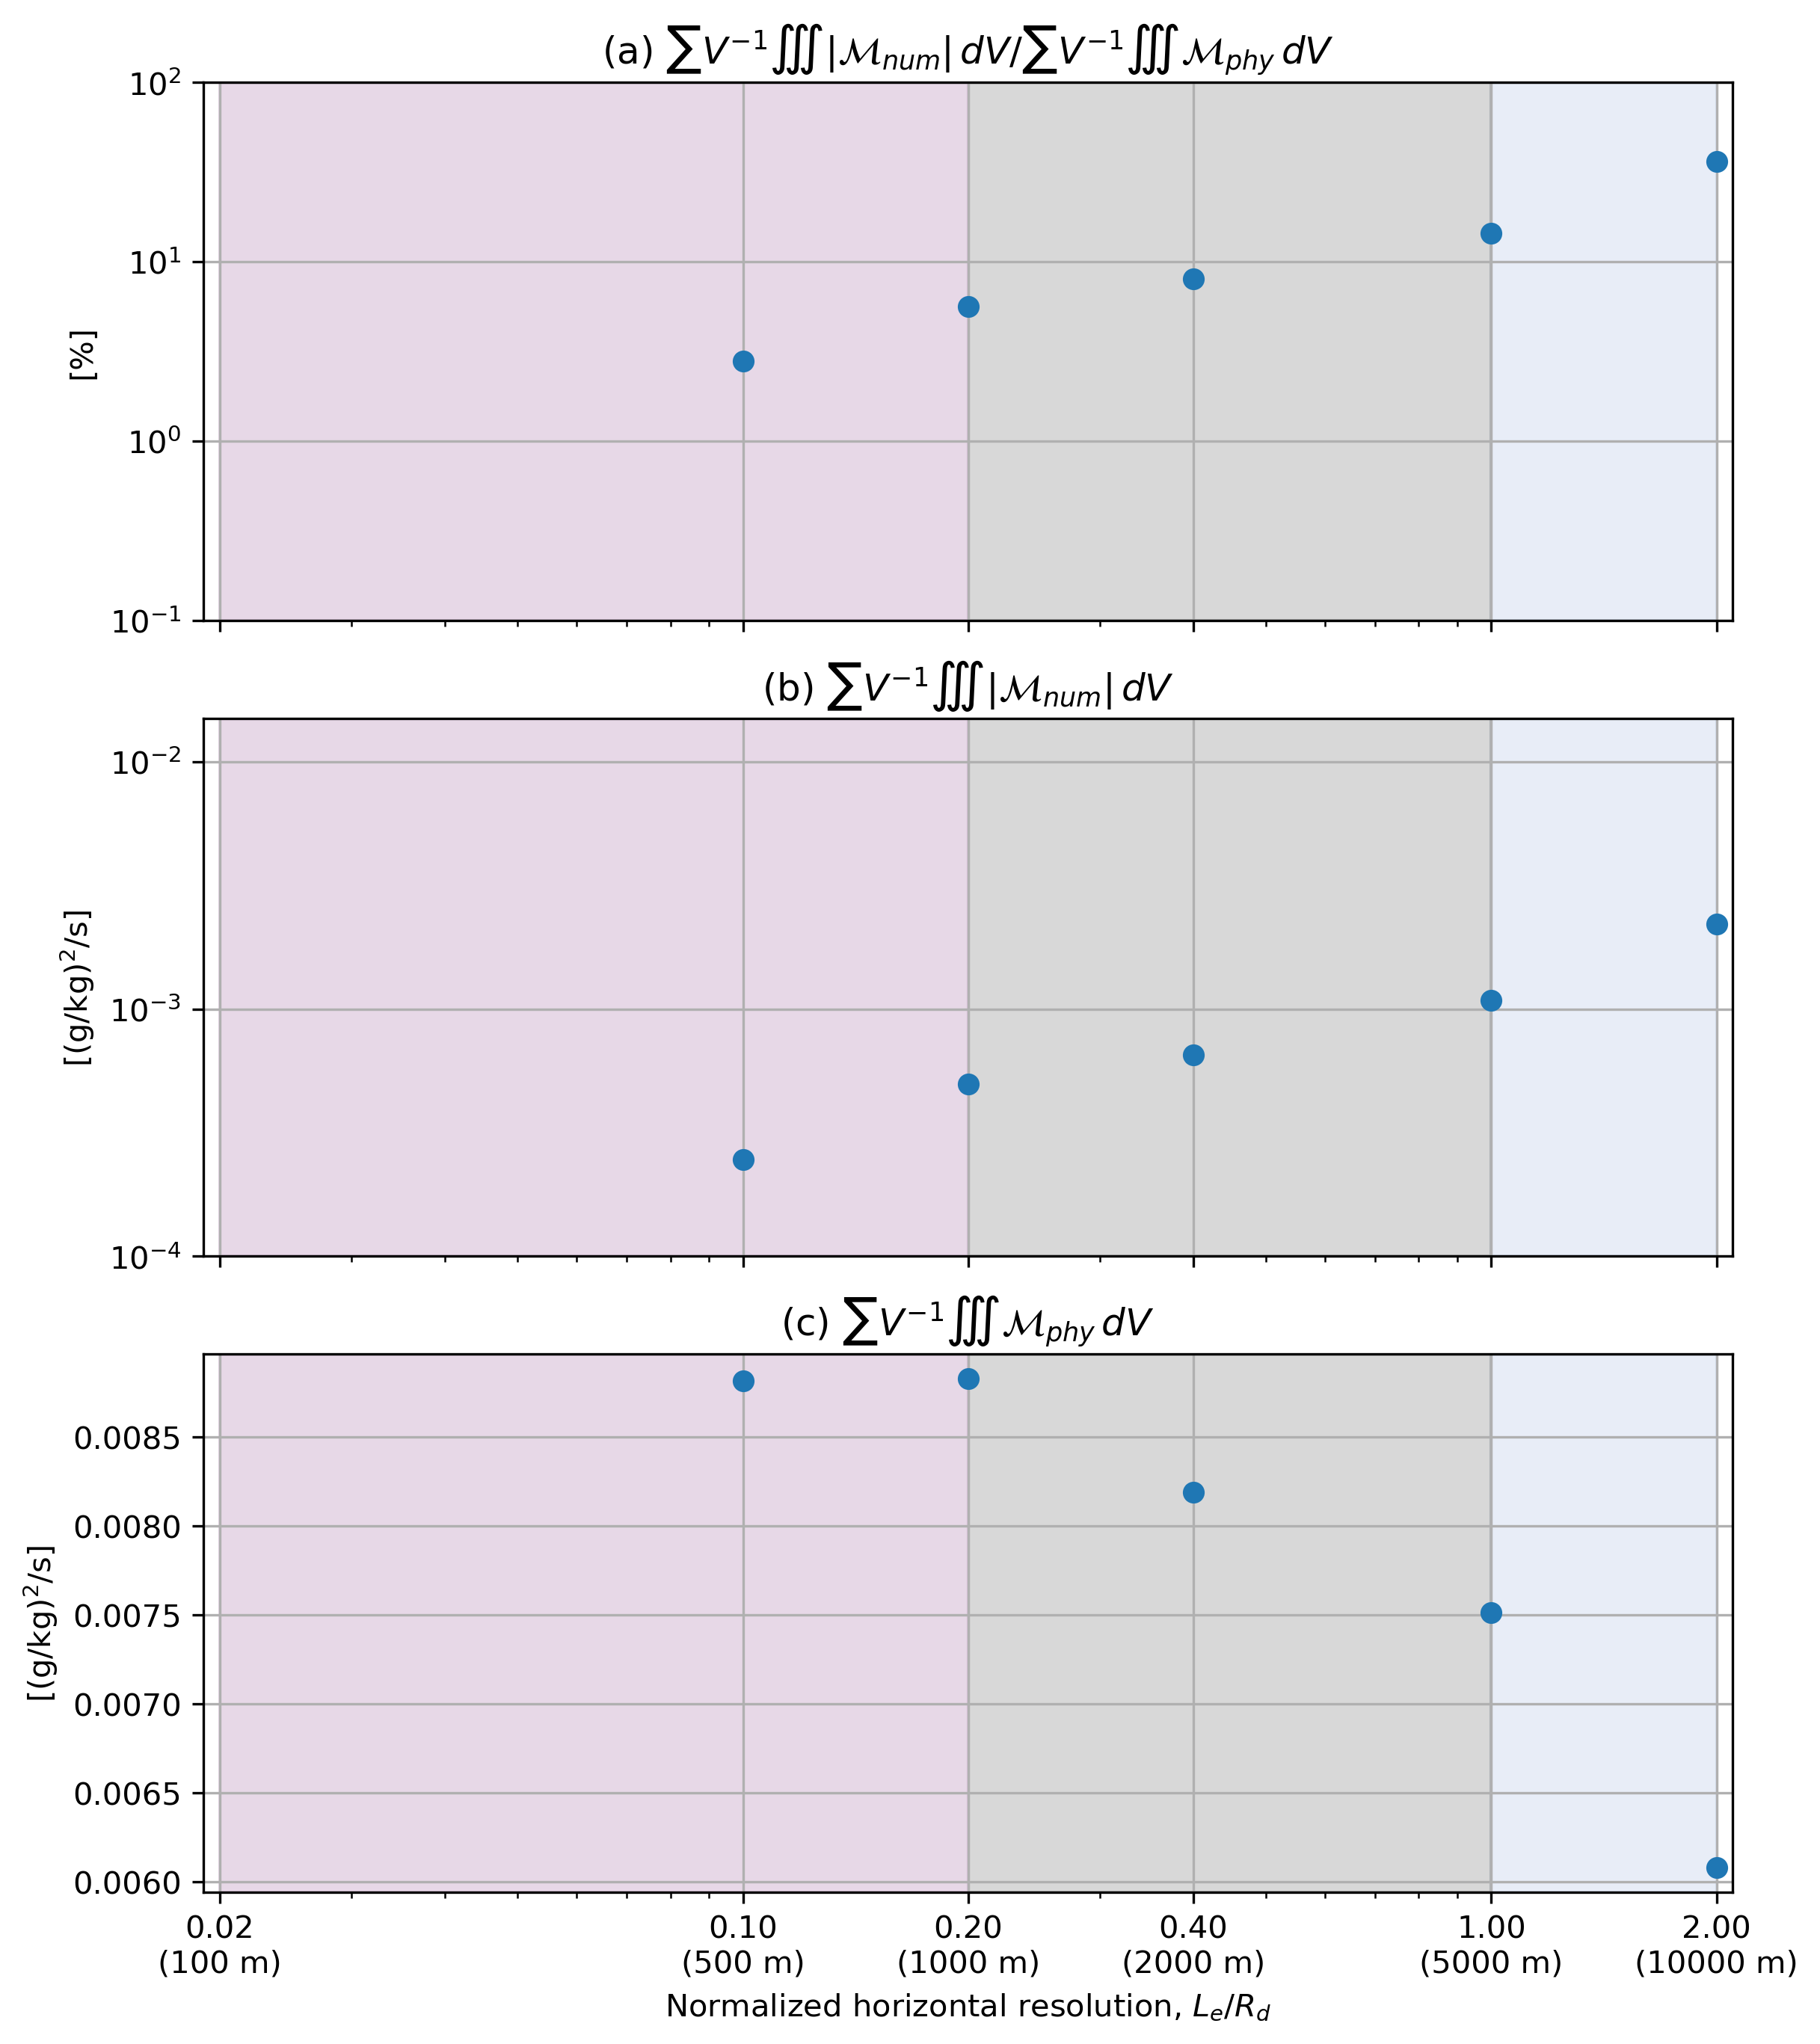

In [69]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import re

# --------------------------------------------------
# Marker and color setup
# --------------------------------------------------
markers = ['o', 'o', 'o', 'o', 'o']  # one per file
colors  = ['tab:blue', 'tab:blue', 'tab:blue', 'tab:blue', 'tab:blue']

fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(8, 9),
                       constrained_layout=True, sharex=True, dpi=300)
linthresh = 1e-1

all_lines, all_labels = [], []

# --------------------------------------------------
# Helper to extract horizontal resolution from filename
# --------------------------------------------------
def horiz_res_from_file(fname):
    """Extract horizontal resolution in meters from filename"""
    m = re.search(r'_(\d+)(km|m)\.nc', fname)
    if m:
        val, unit = int(m.group(1)), m.group(2)
        return val * 1000 if unit == 'km' else val
    else:
        raise ValueError(f"Cannot parse resolution from {fname}")

# --------------------------------------------------
# Loop over resolutions in low → high
# --------------------------------------------------
for i, res in enumerate(resolutions):
    dsm = xr.open_dataset(mix_map[res])

    # Horizontal resolution in meters, normalized
    x_val = horiz_res_from_file(mix_map[res]) / 5000.0

    # --- Physical mixing ---
    line_phy, = ax[2].plot(x_val, np.abs(dsm.Mphy_salt).sum().values,
                           marker=markers[i], linestyle='-', color=colors[i],
                           lw=1, markersize=6, label=f"{res} physical")

    # --- Numerical mixing absolute value ---
    line_num, = ax[1].plot(x_val, np.abs(dsm.Mnum_salt).sum().values,
                           marker=markers[i], linestyle='--', color=colors[i],
                           lw=1, markersize=6, label=f"{res} numerical")

    # --- Ratio numerical / physical ---
    ratio = ((np.abs(dsm.Mnum_salt).sum().values) / (dsm.Mphy_salt.sum().values)) * 100
    line_ratio, = ax[0].plot(x_val, ratio,
                             marker=markers[i], linestyle='-', color=colors[i],
                             lw=1, markersize=6, label=f"{res} ratio")

    # Store for legend
    all_lines.extend([line_ratio, line_num, line_phy])
    all_labels.extend([f"{res} ratio", f"{res} numerical", f"{res} physical"])

# --------------------------------------------------
# Axis formatting
# --------------------------------------------------
ticks_to_show = [0.02, 0.1, 0.2, 0.4, 1.0, 2.0]
for i in range(3):
    ax[i].grid(True)
    ax[i].semilogx()
    ax[i].set_xlim(0.019, 2.1)
    ax[i].set_xticks(ticks_to_show)
    ax[i].set_xticklabels([f"{val:.2f}\n({int(val*5000)} m)" for val in ticks_to_show])
    ax[i].axvspan(1, 2, color='#c7d3ec', alpha=0.4)
    ax[i].axvspan(0.2, 1, color='gray', alpha=0.3)
    ax[i].axvspan(0.02, 0.2, color='#d8bfd8', alpha=0.6)
ax[-1].set_xlabel('Normalized horizontal resolution, $L_e/R_d$')

# Axis-specific formatting
ax[0].set_title(r'(a) $\sum V^{-1} \iiint |\mathcal{M}_{num}| \, dV /  \sum V^{-1} \iiint \mathcal{M}_{phy} \, dV$')
ax[0].set_ylabel(r'[%]')
ax[0].set_yscale('symlog', linthresh=linthresh)
ax[0].set_ylim(0.1, 100)

ax[1].set_title(r'(b) $\sum V^{-1} \iiint |\mathcal{M}_{num}| \, dV$')
ax[1].set_ylabel(r'[(g/kg)$^2$/s]')
ax[1].set_yscale('symlog', linthresh=1e-5)
ax[1].set_ylim(0.0001, 0.015)

ax[2].set_title(r'(c) $\sum V^{-1} \iiint \mathcal{M}_{phy} \, dV$')
ax[2].set_ylabel(r'[(g/kg)$^2$/s]')

# Legend
# ax[0].legend(all_lines, all_labels, loc='lower right', fontsize=9, borderaxespad=0)

# plt.savefig('scatter_plots_single_vert_res.png', dpi=500)
plt.show()
